# Clasificador bayesiano ingenuo

In [82]:
# Importamos los módulos necesarios
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Generamos una función para visualizar los patrones en dos dimensiones
def plot2D(x1, x2, y, axis, labels, caption):
  fig, ax = plt.subplots()
  for g in np.unique(y):
    i = np.where(y == g)[0]
    ax.scatter(x1[i], x2[i], color = labels[g], label = g)
  plt.xlabel(axis[0])
  plt.ylabel(axis[1])
  plt.title(caption)
  ax.legend()

## Ejemplo I

En este ejemplo, usamos un clasificador bayesiano ingenuo para el problema de decidir si podemos salir a jugar golf o no.

En el caso Scikit-learn, su implementación del clasificador bayesiano ingenuo maneja una versión específica para variables categóricas, pero éstas deben estar codificadas como valores enteros. Por esta razón, el dataset que hemos trabajado en ocasiones anteriores debe sufrir una modificación: cambiar cada categoría de las variables independientes a un valor numérico.

In [83]:
# Leemos los datos que usaremos
weather = pd.read_csv("https://raw.githubusercontent.com/jcobayliss/TC3002B-M2/refs/heads/main/datasets/weather.csv")

# Separamos las variables independientes de la dependiente
X = weather.drop("Play", axis = 1)
y = weather["Play"]

# Convertimos las variables categóricas a numéricas discretas
encoder = OrdinalEncoder()
X = encoder.fit_transform(X)

# Creamos un modelo de clasificación usando bayes ingenuo
model = CategoricalNB()

# Entrenamos el modelo usando todos los datos disponibles (no recomendado, se hace con fines académicos)
model.fit(X, y)

# Realizamos la predicción usando todos los datos disponibles (no recomendado, se hace con fines académicos)
prediction = model.predict(X)

# Generamos la matriz de confusión
confusion_matrix(y, prediction)

array([[4, 1],
       [0, 9]])

# Ejemplo II

En este ejemplo, trabajamos con variables independientes cuantitativas para clasificar correctamente un problema. Sin embargo, es importante mencionar que el clasificador bayesiano ingenuo requiere que las variables independientes cuantitativas sigan una distribución normal. Esta condición, no se cumple en este caso y por eso se observa un desempeño limitado.

In [84]:
# Leemos los datos que usaremos
data =  pd.read_csv("https://raw.githubusercontent.com/jcobayliss/TC3002B-M2/refs/heads/main/datasets/extreme.csv")

# Separamos las variables independientes de la dependiente
X = data.drop("Class", axis = 1)
y = data["Class"]

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.60, stratify = y, random_state = 500)

# Creamos un modelo de clasificación usando bayes ingenuo
model = GaussianNB()

# Entrenamos el modelo usando los datos de entrenamiento
model.fit(X_train, y_train)

# Realizamos la predicción usando los datos de prueba
prediction = model.predict(X_test)

# Generamos la matriz de confusión
confusion_matrix(y_test, prediction)

array([[140, 260],
       [  0, 400]])

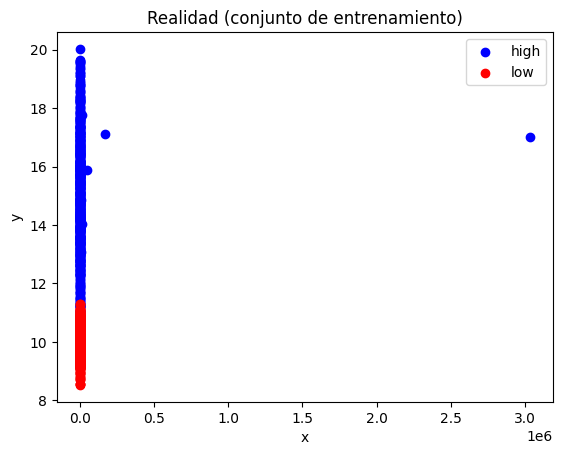

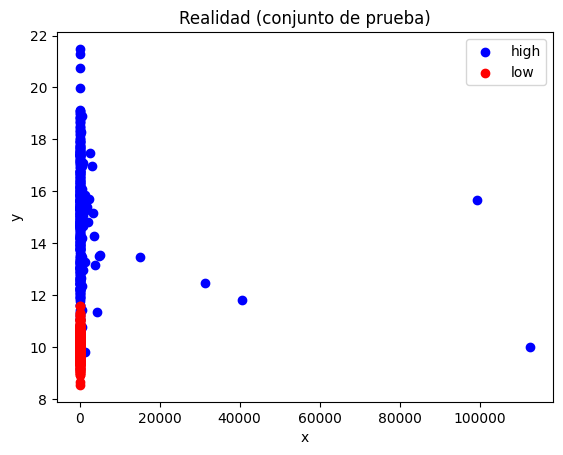

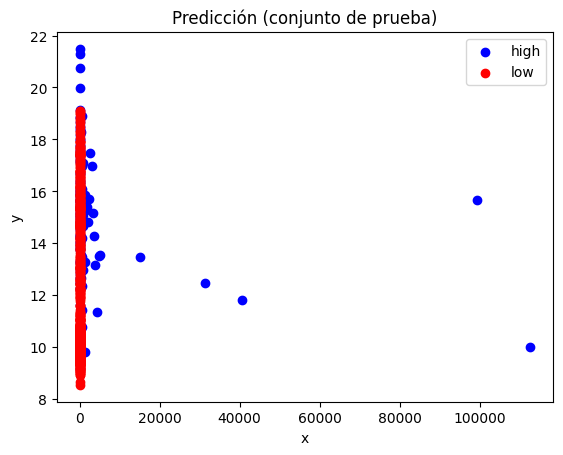

In [85]:
# Asociamos un color a cada etiqueta de la clase
labels = {"high": "blue", "low": "red"}

# Visualizamos el patrón 2D de la realidad en el conjunto de entrenamiento
x1 = X_train.iloc[:, 0].values
x2 = X_train.iloc[:, 1].values
y = y_train
plot2D(x1, x2, y, ["x", "y"], labels, "Realidad (conjunto de entrenamiento)")

# Visualizamos el patrón 2D de la realidad en el conjunto de prueba
x1 = X_test.iloc[:, 0].values
x2 = X_test.iloc[:, 1].values
y = y_test
plot2D(x1, x2, y, ["x", "y"], labels, "Realidad (conjunto de prueba)")

# Visualizamos el patrón 2D de la predicción en el conjunto de prueba
x1 = X_test.iloc[:, 0].values
x2 = X_test.iloc[:, 1].values
y = prediction
plot2D(x1, x2, y,  ["x", "y"], labels, "Predicción (conjunto de prueba)")

## Ejemplo III

Cuando no se cumple la normalidad de los datos, algunas veces es suficiente utilizar una transformación de datos para cumplir con el requisito.

In [86]:
# Leemos los datos que usaremos
data =  pd.read_csv("https://raw.githubusercontent.com/jcobayliss/TC3002B-M2/refs/heads/main/datasets/extreme.csv")

# Separamos las variables independientes de la dependiente
X = data.drop("Class", axis = 1)
y = data["Class"]

# Tratamos de cumplir la normalidad de los datos mediante una transformación logarítmica
X = np.log(X)

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.60, stratify = y, random_state = 500)

# Creamos un modelo de clasificación usando bayes ingenuo
model = GaussianNB()

# Entrenamos el modelo usando los datos de entrenamiento
model.fit(X_train, y_train)

# Realizamos la predicción usando los datos de prueba
prediction = model.predict(X_test)

# Generamos la matriz de confusión
confusion_matrix(y_test, prediction)

array([[400,   0],
       [  0, 400]])

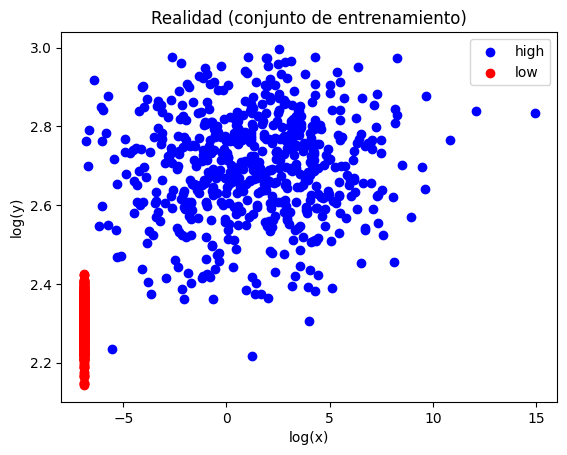

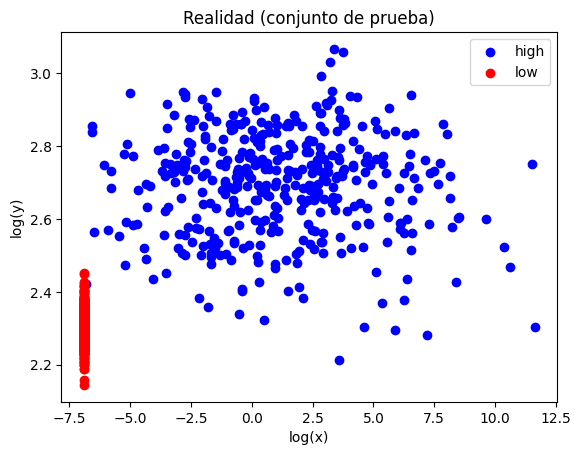

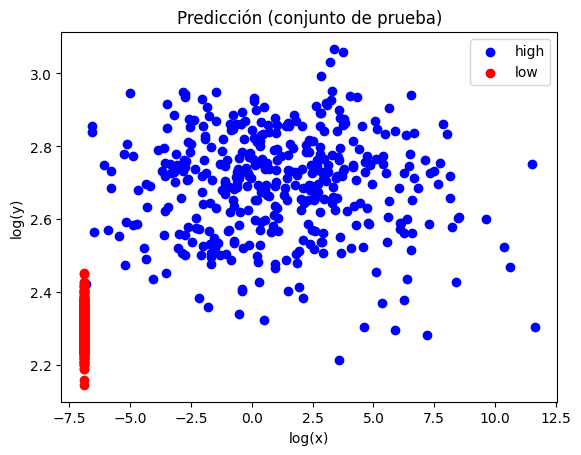

In [87]:
# Asociamos un color a cada etiqueta de la clase
labels = {"high": "blue", "low": "red"}

# Visualizamos el patrón 2D de la realidad en el conjunto de entrenamiento
x1 = X_train.iloc[:, 0].values
x2 = X_train.iloc[:, 1].values
y = y_train
plot2D(x1, x2, y, ["log(x)", "log(y)"], labels, "Realidad (conjunto de entrenamiento)")

# Visualizamos el patrón 2D de la realidad en el conjunto de prueba
x1 = X_test.iloc[:, 0].values
x2 = X_test.iloc[:, 1].values
y = y_test
plot2D(x1, x2, y, ["log(x)", "log(y)"], labels, "Realidad (conjunto de prueba)")

# Visualizamos el patrón 2D de la predicción en el conjunto de prueba
x1 = X_test.iloc[:, 0].values
x2 = X_test.iloc[:, 1].values
y = prediction
plot2D(x1, x2, y, ["log(x)", "log(y)"], labels, "Predicción (conjunto de prueba)")